# ML Week 13: Manipulating Images

### How do we actually handle image data?

In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ------------------- -------------------- 19.9/40.2 MB 110.2 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 102.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


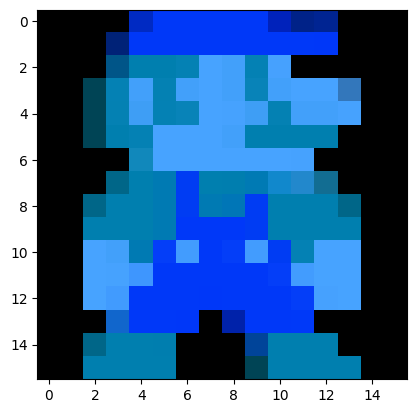

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("mario.png") # [:,:,::-1]
plt.imshow(img)

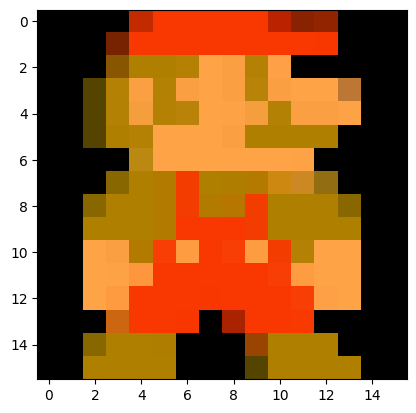

In [2]:
img = cv2.imread("mario.png")[:,:,::-1]
plt.imshow(img)

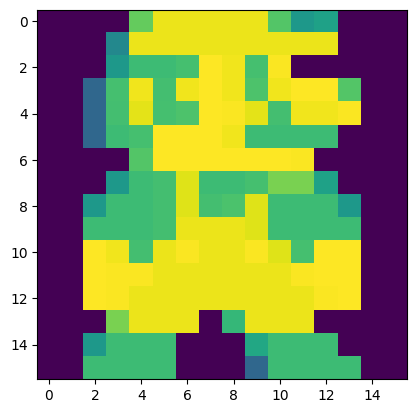

In [8]:
plt.imshow(img[:,:,0])

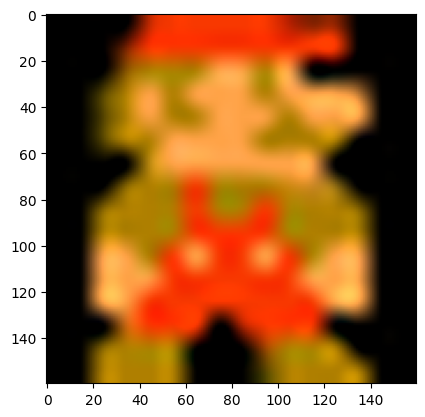

: 

In [ ]:
res = cv2.resize(img,None,fx=10, fy=10, interpolation = cv2.INTER_CUBIC)
plt.imshow(res)

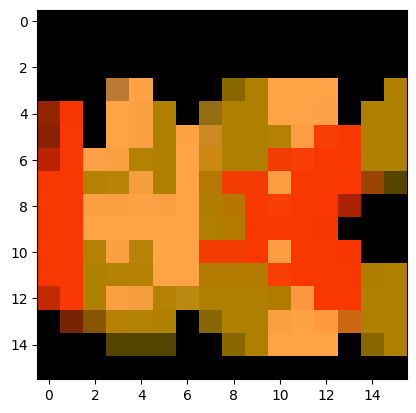

In [22]:
import numpy as np
 
# Load the image
image = img
 
# Get the image dimensions
height, width = image.shape[:2]
 
# Define the rotation center
center = (width // 2, height // 2)
 
# Define the rotation angle
angle = 90  # Rotate by 45 degrees
 
# Define the scaling factor
scale = 1.0  # No scaling
 
# Get the rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
 
# Perform the rotation
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
 
# Display the result
plt.imshow(rotated_image)
 

In [14]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [15]:
img_gray.shape

(16, 16)

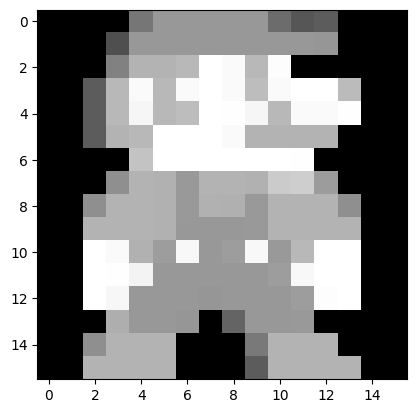

In [76]:
plt.imshow(img_gray, cmap='gray')

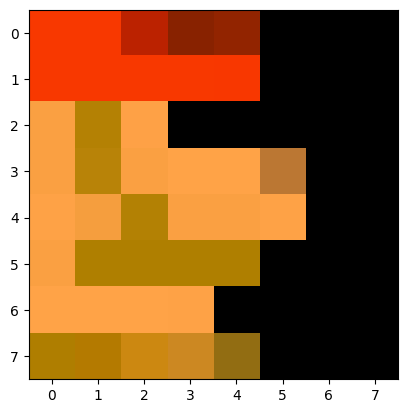

In [27]:
crop = img[0:8,8:16]
plt.imshow(crop)

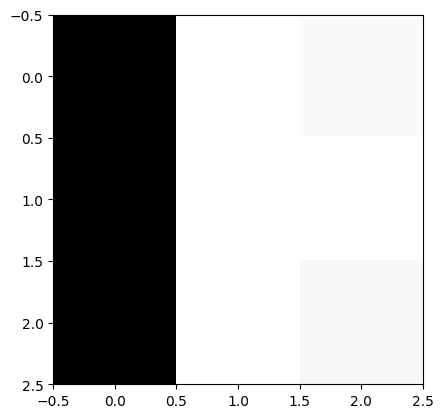

In [48]:
crop = img_gray[10:13,1:4]
plt.imshow(crop, cmap='gray')

In [50]:
M = np.random.rand(3,3)
M*crop

array([[  0.        ,  30.72246397,   8.910038  ],
       [  0.        ,  47.01500786,  87.0274562 ],
       [  0.        ,  87.48004907, 147.58656015]])

In [63]:
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
np.sum(kernel * crop)

np.int64(361)

In [89]:
kernel = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
kernel = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernel = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernel = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

In [90]:
convolved_img = np.zeros((img.shape[0] - 2, img.shape[1] - 2))
for i in range(0,img.shape[0]-2):
    for j in range(0, img.shape[1]-2):
        convolution = np.sum(kernel * img_gray[i:i+3,j:j+3])
        convolved_img[i,j] = convolution

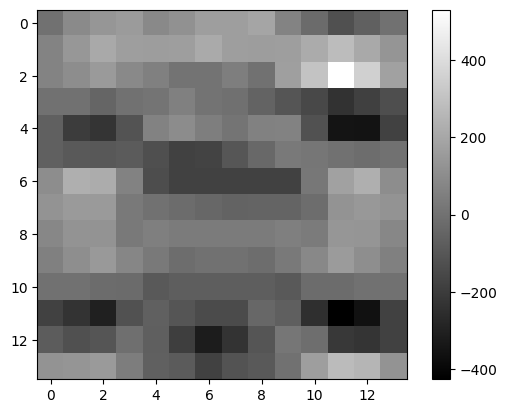

In [91]:
plt.imshow(convolved_img, cmap='gray')
plt.colorbar()